## Import the libraries we will use

In [141]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kruskal, mannwhitneyu



# Upload the dataset

In the first we upload our data set

In [142]:
from google.colab import files
uploaded = files.upload()

Saving Nutrition BMINDS Food Insecurity Survey and stress (Responses)_before_u[pdate.xlsx to Nutrition BMINDS Food Insecurity Survey and stress (Responses)_before_u[pdate (1).xlsx


here we specify the sheet number because the file has 2 sheets

In [143]:
df = pd.read_excel(list(uploaded.keys())[0], sheet_name=0)

explore our data

In [144]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1093 entries, 0 to 1092
Data columns (total 96 columns):
 #   Column                                                                                                                                                                        Non-Null Count  Dtype         
---  ------                                                                                                                                                                        --------------  -----         
 0   Timestamp                                                                                                                                                                     1093 non-null   datetime64[ns]
 1    What is your gender?                                                                                                                                                         1093 non-null   object        
 2   What is your age?                               

In [145]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: Timestamp
<DatetimeArray>
['2022-09-05 13:33:54.552000', '2022-09-05 14:24:32.823000',
 '2022-09-05 14:57:44.437000', '2022-09-05 18:26:04.941000',
 '2022-09-07 21:04:54.095000', '2022-09-07 22:08:01.142000',
 '2022-09-07 22:17:19.986000', '2022-09-07 22:22:20.138000',
 '2022-09-07 23:08:28.282000', '2022-09-08 06:47:34.880000',
 ...
 '2022-10-12 14:32:42.962000', '2022-10-12 15:31:48.376000',
 '2022-10-12 15:54:39.303000', '2022-10-12 18:11:09.798000',
 '2022-10-12 18:31:23.806000', '2022-10-12 21:01:42.736000',
 '2022-10-12 21:03:28.478000', '2022-10-13 00:16:33.858000',
 '2022-10-13 10:45:41.716000', '2022-10-13 10:55:42.420000']
Length: 1024, dtype: datetime64[ns]

Column:  What is your gender?
['Male' 'Female']

Column: What is your age?
['18-22' '50 and older' '22-29' '40-49' '30-39' '23-29' nan]

Column: Are you currently enrolled in college?
['Yes' 'No' nan]

Column:  What region do you live in ?
['North America/Central America' 'Europe' 'Asia' 'Australia\xa0'
 'South 

### Check the count and percentage of missing values for each column

In [146]:
missing_table = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': round((df.isnull().sum() / len(df)) * 100, 2)
})

missing_table = missing_table.sort_values(by='Missing_Count', ascending=False)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

missing_table


,Column,Missing_Count,Missing_Percentage
Email Address,Email Address,1093,100.00
"During the past 30 days, about how often did you feel worthless?","During the past 30 days, about how often did y...",489,44.74
How often did you feel so depressed that nothing could cheer you up?,How often did you feel so depressed that nothi...,414,37.88
"During the past 30 days, about how often did you feel hopeless - all of the time, most of the time, some of the time, a little of the time, or none of the time?","During the past 30 days, about how often did y...",327,29.92
"During the past 7 days, how many days did you exercise for at least 20 minutes?","During the past 7 days, how many days did you ...",183,16.74
"During the past 30 days, about how often did you feel that everything was an effort?","During the past 30 days, about how often did y...",135,12.35
"During the past 30 days, about how often did you feel restless or fidgety?","During the past 30 days, about how often did y...",115,10.52
"How many times per week, on average, do you engage in physical activity for at least 20 minutes a day?","How many times per week, on average, do you en...",106,9.70
"About how often during the past 30 days did you feel nervous - would you say all of the time, most of the time, some of the time, a little of the time, or none of the time?",About how often during the past 30 days did yo...,65,5.95
What is the total income of your primary household?,What is the total income of your primary house...,34,3.11


## Cleaning the data with Columns and row filtering
1.   in the first we drop the duplicated records
2.   then we drop the timestamp and email columns
3.   we drop any column that has more than 5 percent missing values



In [147]:

df_selected=df.copy()
df_selected.drop_duplicates(inplace = True)
df_selected = df_selected.drop(df_selected.columns[[0, 95]], axis=1)
df_selected = df_selected.applymap(lambda x: x.lower().strip() if isinstance(x, str) else x)

missing_percentage = df_selected.isnull().mean() * 100

cols_to_drop = missing_percentage[missing_percentage > 5].index


df_selected.drop(columns=cols_to_drop, inplace=True)
print("dropped columns:")
print(cols_to_drop)


dropped columns:
Index(['How many times per week, on average, do you engage in physical activity for at least 20 minutes a day?',
       'About how often during the past 30 days did you feel nervous - would you say all of the time, most of the time, some of the time, a little of the time, or none of the time?',
       'During the past 30 days, about how often did you feel hopeless - all of the time, most of the time, some of the time, a little of the time, or none of the time?',
       'During the past 30 days, about how often did you feel restless or fidgety?',
       'How often did you feel so depressed that nothing could cheer you up?',
       'During the past 30 days, about how often did you feel that everything was an effort?',
       'During the past 30 days, about how often did you feel worthless? ',
       'During the past 7 days, how many days did you exercise for at least 20 minutes?'],
      dtype='object')


/tmp/ipython-input-4043279295.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_selected = df_selected.applymap(lambda x: x.lower().strip() if isinstance(x, str) else x)


### here when see the info of our data after cleaning its has **1024 row** and **85 columns**

In [148]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1024 entries, 0 to 1023
Data columns (total 86 columns):
 #   Column                                                                                                                                                 Non-Null Count  Dtype  
---  ------                                                                                                                                                 --------------  -----  
 0    What is your gender?                                                                                                                                  1024 non-null   object 
 1   What is your age?                                                                                                                                      1023 non-null   object 
 2   Are you currently enrolled in college?                                                                                                                 1023 non-null   object

### but some of our columns still have missing values

In [149]:
missing_table = pd.DataFrame({
    'Column': df_selected.columns,
    'Missing_Count': df_selected.isnull().sum(),
    'Missing_Percentage': round((df_selected.isnull().sum() / len(df)) * 100, 2)
})

missing_table = missing_table.sort_values(by='Missing_Count', ascending=False)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

missing_table

,Column,Missing_Count,Missing_Percentage
What is the total income of your primary household?,What is the total income of your primary house...,32,2.93
26. I don't know; I can't understand what I am doing in school.,26. I don't know; I can't understand what I am...,29,2.65
"25. For the ""high"" feeling that I experience while reading about various interesting subjects.","25. For the ""high"" feeling that I experience w...",27,2.47
24. Because I believe that a few additional years of education will improve my competence as a worker.,24. Because I believe that a few additional ye...,27,2.47
6. For the pleasure I experience while surpassing myself in my studies.,6. For the pleasure I experience while surpass...,27,2.47
14. Because of the fact that when I succeed in college I feel important.,14. Because of the fact that when I succeed in...,26,2.38
27. Because college allows me to experience a personal satisfaction in my quest for excellence in my studies.,27. Because college allows me to experience a ...,26,2.38
16. For the pleasure that I experience in broadening my knowledge about subjects which appeal to me.,16. For the pleasure that I experience in broa...,26,2.38
18. For the pleasure that I experience when I feel completely absorbed by what certain authors have written.,18. For the pleasure that I experience when I ...,26,2.38
28. Because I want to show myself that I can succeed in my studies.,28. Because I want to show myself that I can s...,26,2.38


In [150]:
df_filled = df_selected.copy()
df_filled= df_filled.dropna()

### Now our data is clean

In [151]:
missing_table = pd.DataFrame({
    'Missing_Count': df_filled.isnull().sum(),
    'Missing_Percentage': round((df_filled.isnull().sum() / len(df)) * 100, 2)
})

missing_table = missing_table.sort_values(by='Missing_Count', ascending=False)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

missing_table

,Missing_Count,Missing_Percentage
What is your gender?,0,0.0
What is your age?,0,0.0
Are you currently enrolled in college?,0,0.0
What region do you live in ?,0,0.0
How many hours do you work in an average week during the school year?,0,0.0
Which of these describes your personal income last year?,0,0.0
What is the total income of your primary household?,0,0.0
Are you or your family eligible for SNAP benefits or any governmental assistance program?,0,0.0
What is the highest level of education you have completed?,0,0.0
What is your cumulative GPA range?,0,0.0


# create metrics with new columns

In [152]:
df_encoded=df_filled.copy()

### FIES Score
in the first we create a new metric its name (FIES) based on 8 columns in our data set in index (12 to 19) that have values(yes,no,not sure or don't know) and assign a numerical value for each one then sum to create two columns (FIES_score) , (FIES level).

In [153]:
fies_cols = df_encoded.columns[12:20]
df_encoded[fies_cols] = df_encoded[fies_cols].replace({
    'no': 0,
    'yes': 1,
    "not sure or don't know": 1
})
df_encoded['FIES_score'] = df_encoded[fies_cols].sum(axis=1)

def fies_category(score):
    if score == 0:
        return 'high food security'
    elif score == 1:
        return 'marginal food security'
    elif 2 <= score <= 4:
        return 'low food security'
    else:
        return 'very low food security'

df_encoded['FIES_level'] = df_encoded['FIES_score'].apply(fies_category)


/tmp/ipython-input-1125714691.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded[fies_cols] = df_encoded[fies_cols].replace({


here we produce 2 columns (FIES level) for categorical classification and (FIES SCORE)for numerical measure

In [154]:
df_encoded["FIES_level"].unique()

array(['high food security', 'low food security',
       'marginal food security', 'very low food security'], dtype=object)

In [155]:
df_encoded["FIES_score"].describe()

,FIES_score
count,862.000000
mean,1.791183
std,2.471772
min,0.000000
25%,0.000000
50%,0.000000
75%,3.000000
max,8.000000


### Resilience Score
here we reversed negatively worded resilience in columns (21,23,25) then summed 6 columns (20–25) to create two columns (Resilience_Total) and classify(Resilience_Level) into "low Resilience", "normal Resilience", "high Resilience".

In [156]:
negative_idx = [21, 23, 25]

for idx in negative_idx:
    df_encoded[idx] = 6 - df_encoded.iloc[:, idx]


df_encoded["Resilience_Total"] = df_encoded.iloc[:, 20:26].sum(axis=1)

def classify_resilience(score):
    if score <= 13:
        return "low Resilience"
    elif score <= 21:
        return "normal Resilience"
    else:
        return "high Resilience"

df_encoded["Resilience_Level"] = df_encoded["Resilience_Total"].apply(classify_resilience)

In [157]:
df_encoded["Resilience_Level"].unique()

array(['normal Resilience', 'high Resilience', 'low Resilience'],
      dtype=object)

In [158]:
df_encoded["Resilience_Total"].describe()

,Resilience_Total
count,862.000000
mean,18.435035
std,2.146726
min,11.000000
25%,17.000000
50%,18.000000
75%,20.000000
max,30.000000


### Stressmindset
like the previous measure we reversed negatively worded items in columns (54,56,58,60) and summed 8 columns (54–61) to create two columns (StressMindset_Total) and (StressMindset_Level) with these categories: "debilitating", "moderate", or "enhancing mindset".

In [159]:
mapping = {
    "strongly disagree": 0,
    "disagree": 1,
    "neither agree nor disagree": 2,
    "agree": 3,
    "strongly agree": 4,
}

def map_text_to_num(x):
    if isinstance(x, str):
        x = x.strip().lower()
        return mapping.get(x, None)
    return x

for idx in range(54, 62):
    df_encoded.iloc[:, idx] = df_encoded.iloc[:, idx].apply(map_text_to_num)


negative_idx = [54, 56, 58, 60]

for idx in negative_idx:
    df_encoded.iloc[:, idx] = 4 - df_encoded.iloc[:, idx]


df_encoded["StressMindset_Total"] = df_encoded.iloc[:, 54:62].sum(axis=1)


def classify_smm(score):
    if score <= 10:
        return "debilitating mindset"
    elif score <= 21:
        return "moderate mindset"
    else:
        return "enhancing mindset"

df_encoded["StressMindset_Total"] = df_encoded["StressMindset_Total"].astype(int)
df_encoded["StressMindset_Level"] = df_encoded["StressMindset_Total"].apply(classify_smm)


In [160]:
df_encoded["StressMindset_Level"].unique()

array(['moderate mindset', 'debilitating mindset', 'enhancing mindset'],
      dtype=object)

In [161]:
df_encoded["StressMindset_Total"].describe()

,StressMindset_Total
count,862.000000
mean,13.709977
std,5.650228
min,0.000000
25%,10.000000
50%,14.000000
75%,17.750000
max,32.000000


### Mental distress or K10
in this measure we mapped 10 responses(the columns from 62 to 71) to numeric values and summ it to create the (K10_total) then classify(K10_category) into “likely to be well”, “moderate disorder”, or “severe disorder”.

In [162]:
k10_mapping = {
    'never': 1,
    'almost never': 2,
    'sometimes': 3,
    'fairly often': 4,
    'very often': 5,
    'none': 1,
    'a little': 2,
    'some': 3,
    'most': 4,
    'all': 5
}

k10_indexes = list(range(62, 72))

for idx in k10_indexes:
    col = df_encoded.iloc[:, idx]

    if col.dtype == 'object':
        df_encoded.iloc[:, idx] = (
            col.astype(str)
            .str.strip()
            .str.lower()
            .map(k10_mapping)
        )
    else:
        df_encoded.iloc[:, idx] = col

df_encoded.iloc[:, k10_indexes] = df_encoded.iloc[:, k10_indexes].astype(float)

df_encoded['K10_total'] = df_encoded.iloc[:, k10_indexes].sum(axis=1, skipna=False)

def classify_k10(score):
    if pd.isna(score):
        return np.nan
    elif score <= 19:
        return 'likely to be well'
    elif score <= 29:
        return 'moderate disorder'
    else:
        return 'severe disorder'

df_encoded['K10_category'] = df_encoded['K10_total'].apply(classify_k10)
df_encoded["K10_total"] = df_encoded["K10_total"].astype(int)

In [163]:
df_encoded["K10_category"].unique()

array(['severe disorder', 'moderate disorder'], dtype=object)

In [164]:
df_encoded["K10_total"].describe()

,K10_total
count,862.000000
mean,32.661253
std,3.550709
min,23.000000
25%,30.000000
50%,32.000000
75%,35.000000
max,46.000000


In [165]:
df_encoded.drop(columns=[21, 23, 25], inplace=True)

In [166]:
df_encoded.head(1)

,What is your gender?,What is your age?,Are you currently enrolled in college?,What region do you live in ?,How many hours do you work in an average week during the school year?,Which of these describes your personal income last year?,What is the total income of your primary household?,Are you or your family eligible for SNAP benefits or any governmental assistance program?,What is the highest level of education you have completed?,What is your cumulative GPA range?,What is your typical dietary style?,"How many times a day, on average, do you think about food (ex. eating food, buying food, your next meal)?","During the last 12 months, was there a time when, because of lack of money or other resources you were worried you would not have enough food to eat?","During the last 12 months, was there a time when, because of lack of money or other resources you were unable to eat healthy and nutritious food?","During the last 12 months, was there a time when, because of lack of money or other resources you ate only a few kinds of foods?","During the last 12 months, was there a time when, because of lack of money or other resources you had to skip a meal?","During the last 12 months, was there a time when, because of lack of money or other resources you ate less than you thought you should?","During the last 12 months, was there a time when, because of lack of money or other resources your household ran out of food?","During the last 12 months, was there a time when, because of lack of money or other resources you were hungry but did not eat?","During the last 12 months, was there a time when, because of lack of money or other resources you went without eating for a whole day?",1. I tend to bounce back quickly after hard times,2. I have a hard time making it through stressful events,3. It does not take me long to recover from a stressful event.,4. It is hard for me to snap back when something bad happens.,5. I usually come through difficult times with little trouble.,6. I tend to take a long time to get over set-backs in my life.,1. Because with only a high-school degree I would not find a high-paying job later on.,2. Because I experience pleasure and satisfaction while learning new things.,3. Because I think that a college education will help me better prepare for the career I have chosen.,4. For the intense feelings I experience when I am communicating my own ideas to others.,"5. Honestly, I don't know; I really feel that I am wasting my time in school.",6. For the pleasure I experience while surpassing myself in my studies.,7. To prove to myself that I am capable of completing my college degree.,8. In order to obtain a more prestigious job later on.,9. For the pleasure I experience when I discover new things never seen before.,10. Because eventually it will enable me to enter the job market in a field that I like.,11. For the pleasure that I experience when I read interesting authors.,"12. I once had good reasons for going to college; however, now I wonder whether I should continue.",13. For the pleasure that I experience while I am surpassing myself in one of my personal accomplishments.,14. Because of the fact that when I succeed in college I feel important.,"15. Because I want to have ""the good life"" later on.",16. For the pleasure that I experience in broadening my knowledge about subjects which appeal to me.,17. Because this will help me make a better choice regarding my career orientation.,18. For the pleasure that I experience when I feel completely absorbed by what certain authors have written.,"19. I can't see why I go to college and frankly, I couldn't care less.",20. For the satisfaction I feel when I am in the process of accomplishing difficult academic activities.,21. To show myself that I am an intelligent person.,22. In order to have a better salary later on.,23. Because my studies allow me to continue to learn about many things that interest me.,24. Because I believe that a few additional years of education will im

In [167]:
df_encoded.columns = df_encoded.columns.str.strip()

In [168]:
df_encoded.columns

Index(['What is your gender?', 'What is your age?',
       'Are you currently enrolled in college?',
       'What region do you live in ?',
       'How many hours do you work in an average week during the school year?',
       'Which of these describes your personal income last year?',
       'What is the total income of your primary household?',
       'Are you or your family eligible for SNAP benefits or any governmental assistance program?',
       'What is the highest level of education you have completed?',
       'What is your cumulative GPA range?',
       'What is your typical dietary style?',
       'How many times a day, on average, do you think about food (ex. eating food, buying food, your next meal)?',
       'During the last 12 months, was there a time when, because of lack of money or other resources you were worried you would not have enough food to eat?',
       'During the last 12 months, was there a time when, because of lack of money or other resources you were unab

In [169]:
selected_columns = [
    'What is your gender?',
    "What is your age?",
    'What is the total income of your primary household?',
    'What is your cumulative GPA range?',
    'FIES_level',
    "FIES_score",
    "Resilience_Total",
    'Resilience_Level',
    "StressMindset_Total",
    'StressMindset_Level',
    'K10_category',
    'On an average week, how many times do you consume fast foods and/or pre-made or packaged food?',
    "K10_total"
]

research_df = df_encoded.copy()

select the columns we need to make our research questions and make encode for categorical cols

In [170]:
research_df['gender_enc'] = research_df['What is your gender?'].map({'male': 0, 'female': 1})
gpa_order = {
    'less than 1': 0, '1.0-1.49': 1, '1.5-1.99': 2, '2.0-2.29': 3,
    '2.3-2.69': 4, '2.7-2.99': 5, '3.0-3.39': 6, '3.4-3.69': 7,
    '3.7-4.0': 8, 'not applicable': -1
}
research_df['gpa_enc'] = research_df['What is your cumulative GPA range?'].map(gpa_order)
income_order = {
    'less than $10,000': 0, '$10,000 to $19,999': 1, '$20,000 to $29,999': 2,
    '$30,000 to $39,999': 3, '$40,000 to $49,999': 4, '$50,000 to $59,999': 5,
    '$60,000 to $69,999': 6, '$70,000 to $79,999': 7, '$80,000 to $89,999': 8,
    '$90,000 to $99,999': 9, '$100,000 to $149,999': 10, '$150,000 to $249,999': 11,
    '$250,000 or more': 12
}
research_df['income_enc'] = research_df['What is the total income of your primary household?'].map(income_order)
ff_order = {
    'never': 0, '1 time': 1, '2 times': 2, '3 times': 3, '4 times': 4, '5 times or more': 5
}
research_df['fast_food_enc'] = research_df['On an average week, how many times do you consume fast foods and/or pre-made or packaged food?'].map(ff_order)
fies_order = {
    'high food security': 3,
    'marginal food security': 2,
    'low food security': 1,
    'very low food security': 0
}
research_df['FIES_level_enc'] = research_df['FIES_level'].map(fies_order)

resilience_order = {
    'low Resilience': 0,
    'normal Resilience': 1,
    'high Resilience': 2
}
research_df['Resilience_level_enc'] = research_df['Resilience_Level'].map(resilience_order)

stressmindset_order = {
    'debilitating mindset': 0,
    'moderate mindset': 1,
    'enhancing mindset': 2
}
research_df['StressMindset_level_enc'] = research_df['StressMindset_Level'].map(stressmindset_order)

k10_order = {
    'moderate disorder': 1,
    'severe disorder': 0
}
research_df['K10_category_enc'] = research_df['K10_category'].map(k10_order)




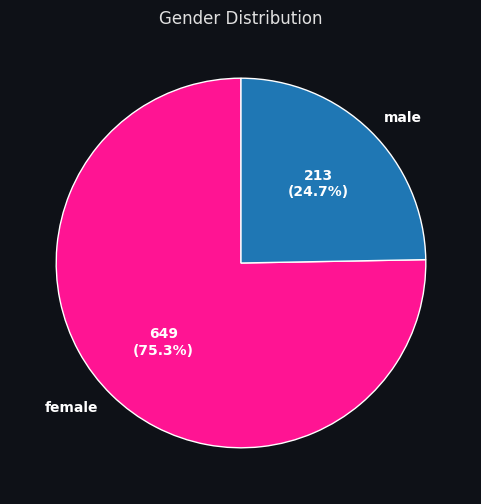

In [171]:
import matplotlib.pyplot as plt

col = 'What is your gender?'
counts = research_df[col].value_counts()

# ألوان أكثر وضوحًا وتباين أعلى
colors = ['#1f77b4' if x.lower()=='male' else '#FF1493' for x in counts.index]

plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=counts.index,
    autopct=lambda p: f'{int(round(p/100*counts.sum()))}\n({p:.1f}%)',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor':'white'},
    textprops={'color':'white', 'weight':'bold'}
)
plt.title('Gender Distribution')
plt.show()


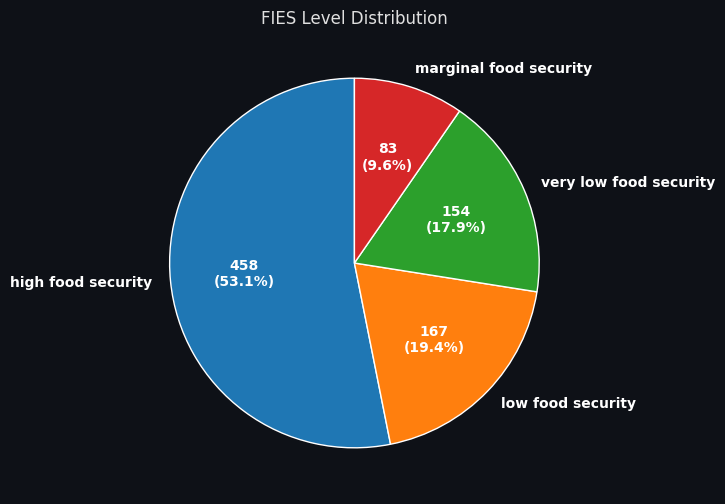

In [172]:
import matplotlib.pyplot as plt

col = 'FIES_level'
counts = research_df[col].value_counts()

# ألوان قوية وواضحة لكل فئة
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'][:len(counts)]

plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=counts.index,
    autopct=lambda p: f'{int(round(p/100*counts.sum()))}\n({p:.1f}%)',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor':'white'},
    textprops={'color':'white', 'weight':'bold'}
)
plt.title('FIES Level Distribution')
plt.show()


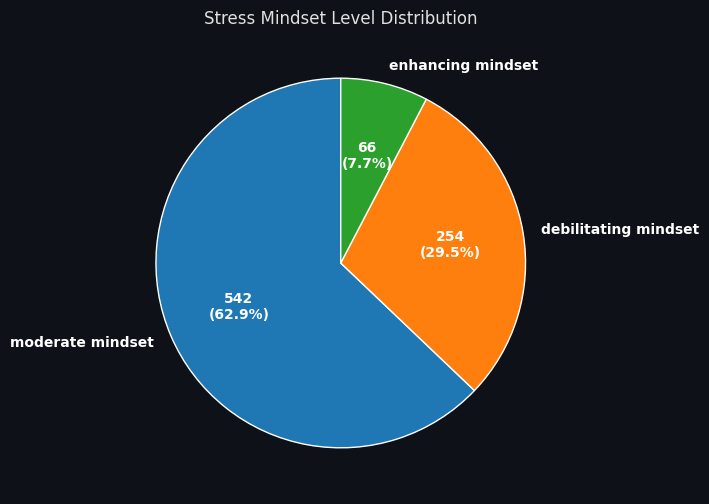

In [173]:
import matplotlib.pyplot as plt

col = 'StressMindset_Level'
counts = research_df[col].value_counts()

# ألوان قوية وواضحة لكل فئة
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'][:len(counts)]

plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=counts.index,
    autopct=lambda p: f'{int(round(p/100*counts.sum()))}\n({p:.1f}%)',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor':'white'},
    textprops={'color':'white', 'weight':'bold'}
)
plt.title('Stress Mindset Level Distribution')
plt.show()


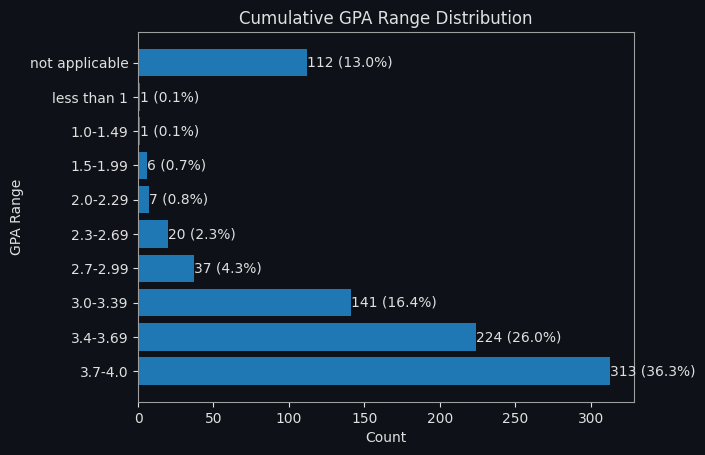

In [174]:
import matplotlib.pyplot as plt
import pandas as pd

col = 'What is your cumulative GPA range?'

gpa_order = [
    '3.7-4.0','3.4-3.69','3.0-3.39','2.7-2.99','2.3-2.69',
    '2.0-2.29','1.5-1.99','1.0-1.49','less than 1','not applicable'
]

# تحويل العمود إلى categorical مع ترتيب محدد
research_df[col] = pd.Categorical(
    research_df[col],
    categories=gpa_order,
    ordered=True
)

# حساب التكرار والنسبة بالترتيب الصحيح
counts = research_df[col].value_counts(sort=False)
percentages = (counts / counts.sum()) * 100

# رسم Horizontal Bar Chart
plt.figure()
bars = plt.barh(counts.index, counts.values)

# كتابة count و percentage على كل bar
for bar, count, perc in zip(bars, counts.values, percentages.values):
    plt.text(
        count,
        bar.get_y() + bar.get_height() / 2,
        f'{int(count)} ({perc:.1f}%)',
        va='center'
    )

plt.xlabel('Count')
plt.ylabel('GPA Range')
plt.title('Cumulative GPA Range Distribution')
plt.show()


['$90,000 to $99,999', '$100,000 to $149,999', '$250,000 or more', '$30,000 to $39,999', '$60,000 to $69,999', ..., '$20,000 to $29,999', '$10,000 to $19,999', '$80,000 to $89,999', '$70,000 to $79,999', '$40,000 to $49,999']
Length: 13
Categories (13, object): ['less than $10,000' < '$10,000 to $19,999' < '$20,000 to $29,999' <
                          '$30,000 to $39,999' ... '$90,000 to $99,999' < '$100,000 to $149,999' <
                          '$150,000 to $249,999' < '$250,000 or more']


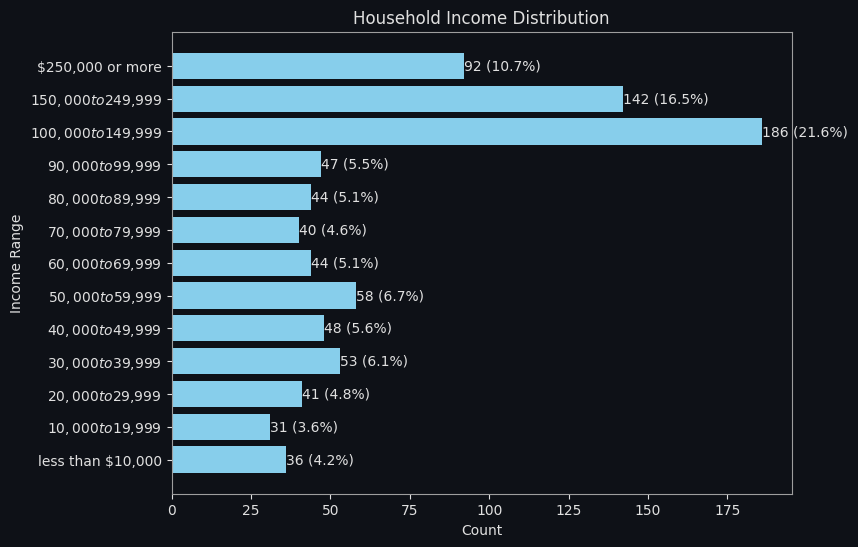

In [175]:
import matplotlib.pyplot as plt
import pandas as pd

col = 'What is the total income of your primary household?'
income_order = [
    'less than $10,000',
    '$10,000 to $19,999',
    '$20,000 to $29,999',
    '$30,000 to $39,999',
    '$40,000 to $49,999',
    '$50,000 to $59,999',
    '$60,000 to $69,999',
    '$70,000 to $79,999',
    '$80,000 to $89,999',
    '$90,000 to $99,999',
    '$100,000 to $149,999',
    '$150,000 to $249,999',
    '$250,000 or more'
]

research_df[col] = pd.Categorical(
    research_df[col],
    categories=income_order,
    ordered=True
)

counts = research_df[col].value_counts(sort=False)
percentages = (counts / counts.sum()) * 100

plt.figure(figsize=(8,6))
bars = plt.barh(counts.index, counts.values, color='skyblue')

for bar, count, perc in zip(bars, counts.values, percentages.values):
    plt.text(
        count,
        bar.get_y() + bar.get_height() / 2,
        f'{int(count)} ({perc:.1f}%)',
        va='center'
    )
print(research_df[col].unique())

plt.xlabel('Count')
plt.ylabel('Income Range')
plt.title('Household Income Distribution')
plt.show()


In [176]:
import pandas as pd

# الأعمدة المراد تلخيصها
columns = ['K10_total',"StressMindset_Total"]  # استبدل بالأعمدة المطلوبة

# إنشاء DataFrame فارغ لتخزين النتائج
summary_df = pd.DataFrame()

# عمل for loop لكل عمود
for col in columns:
    stats = research_df[col].describe()
    stats_df = pd.DataFrame(stats).T
    stats_df.index = [col]
    summary_df = pd.concat([summary_df, stats_df])

summary_df


,count,mean,std,min,25%,50%,75%,max
K10_total,862.0,32.661253,3.550709,23.0,30.0,32.0,35.00,46.0
StressMindset_Total,862.0,13.709977,5.650228,0.0,10.0,14.0,17.75,32.0


In [177]:
K10_total = research_df['K10_total']

stat, p_value = shapiro(K10_total)
print(f'Statistic: {stat}')
print(f'p-value = {p_value:.3e}')

if p_value > 0.05:
    print("Normal distribution")
else:
    print("Not normal distribution")

Statistic: 0.9831011345344275
p-value = 1.993e-08
Not normal distribution


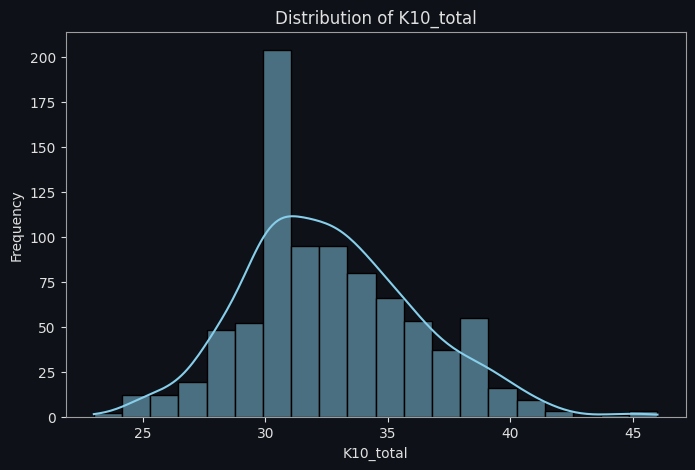

In [178]:
K10_total = research_df['K10_total']

plt.figure(figsize=(8,5))
sns.histplot(K10_total, kde=True, bins=20, color='skyblue')
plt.title('Distribution of K10_total')
plt.xlabel('K10_total')
plt.ylabel('Frequency')
plt.show()

In [179]:
corr1, p = spearmanr(research_df['FIES_level_enc'], research_df['K10_total'])
print(f"1. FIES_level vs K10_total: Spearman r = {corr1:.2f}, p-value = {p:.3e}")
if p < 0.05:
    print("النتيجة دالة إحصائيًا → هناك علاقة بين FIES_level و K10_total")
else:
    print("النتيجة غير دالة إحصائيًا → لا يوجد دليل على وجود علاقة بين FIES_level و K10_total")

1. FIES_level vs K10_total: Spearman r = -0.24, p-value = 5.982e-13
النتيجة دالة إحصائيًا → هناك علاقة بين FIES_level و K10_total


/tmp/ipython-input-214693366.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


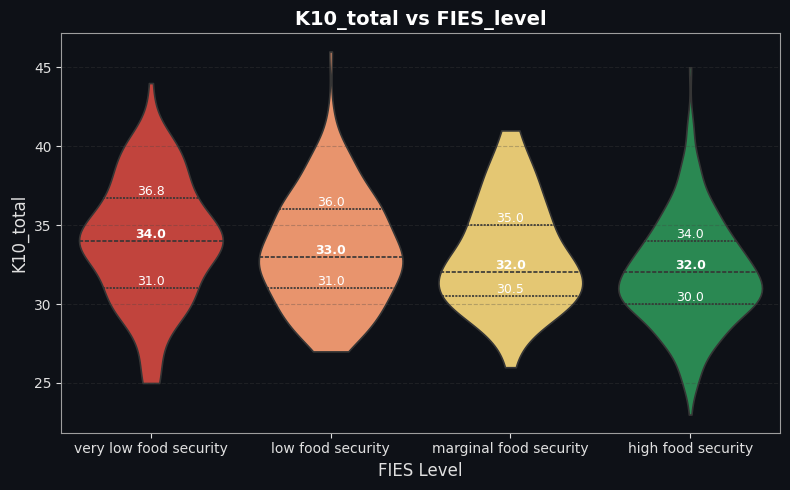

In [180]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams.update({
    'figure.facecolor': '#0E1117',
    'axes.facecolor': '#0E1117',
    'axes.edgecolor': '#9E9E9E',
    'axes.labelcolor': '#E0E0E0',
    'xtick.color': '#E0E0E0',
    'ytick.color': '#E0E0E0',
    'text.color': '#E0E0E0'
})

order = ['very low food security', 'low food security', 'marginal food security', 'high food security']

research_df['FIES_level'] = pd.Categorical(research_df['FIES_level'], categories=order, ordered=True)

fies_colors = {
    'very low food security': '#d73027',
    'low food security': '#fc8d59',
    'marginal food security': '#f7d060',
    'high food security': '#1a9850'
}

plt.figure(figsize=(8,5))
ax = sns.violinplot(
    x='FIES_level',
    y='K10_total',
    data=research_df,
    palette=fies_colors,
    inner='quartile',
    order=order,
    linewidth=1.2,
    cut=0
)

for i, level in enumerate(order):
    values = research_df.loc[research_df['FIES_level']==level, 'K10_total'].dropna()
    q1 = np.percentile(values, 25)
    median = np.median(values)
    q3 = np.percentile(values, 75)

    ax.text(i, q1, f'{q1:.1f}', ha='center', va='bottom', color='#FFFFFF', fontsize=9)
    ax.text(i, median, f'{median:.1f}', ha='center', va='bottom', color='#FFFFFF', fontsize=9, fontweight='bold')
    ax.text(i, q3, f'{q3:.1f}', ha='center', va='bottom', color='#FFFFFF', fontsize=9)

plt.title('K10_total vs FIES_level', fontsize=14, fontweight='bold', color='#FFFFFF')
plt.xlabel('FIES Level', fontsize=12, color='#E0E0E0')
plt.ylabel('K10_total', fontsize=12, color='#E0E0E0')
plt.grid(axis='y', linestyle='--', alpha=0.3, color='#444444')
plt.tight_layout()
plt.show()


In [181]:
K10_total = research_df['StressMindset_Total']

stat, p_value = shapiro(K10_total)
print(f'Statistic: {stat}')
print(f'p-value = {p_value:.3e}')

if p_value > 0.05:
    print("Normal distribution")
else:
    print("Not normal distribution")

Statistic: 0.9921370391284773
p-value = 1.541e-04
Not normal distribution


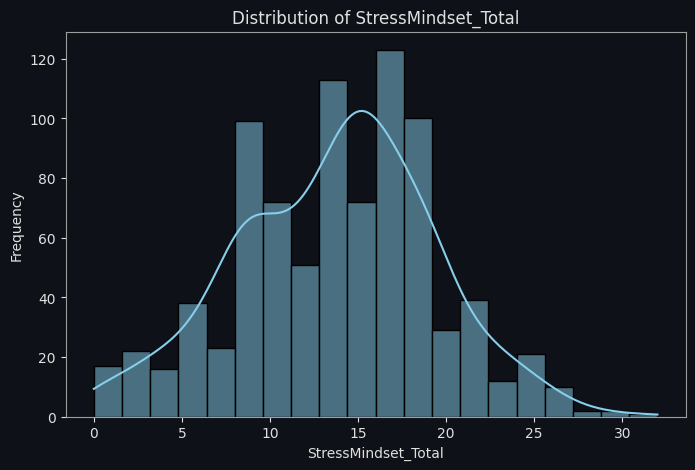

In [182]:
K10_total = research_df['StressMindset_Total']

plt.figure(figsize=(8,5))
sns.histplot(K10_total, kde=True, bins=20, color='skyblue')
plt.title('Distribution of StressMindset_Total')
plt.xlabel('StressMindset_Total')
plt.ylabel('Frequency')
plt.show()

In [183]:
from scipy.stats import mannwhitneyu

male_scores = research_df[research_df['What is your gender?'] == 'male']['StressMindset_Total']
female_scores = research_df[research_df['What is your gender?'] == 'female']['StressMindset_Total']

stat, p_value = mannwhitneyu(male_scores, female_scores, alternative='two-sided')
print(f"Mann-Whitney U = {stat:.2f}, p-value = {p_value:.3e}")

if p_value < 0.05:
    print("يوجد فرق دال إحصائيًا بين الذكور والإناث في StressMindset_Total")
else:
    print("لا يوجد فرق دال إحصائيًا بين الذكور والإناث")


Mann-Whitney U = 81758.00, p-value = 5.942e-05
يوجد فرق دال إحصائيًا بين الذكور والإناث في StressMindset_Total


/tmp/ipython-input-290917685.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


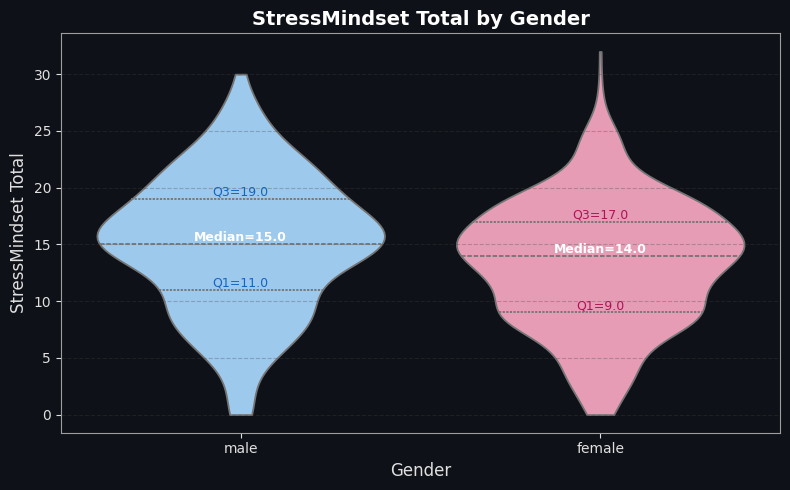

In [184]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

plt.rcParams.update({
    'figure.facecolor': '#0E1117',
    'axes.facecolor': '#0E1117',
    'axes.edgecolor': '#9E9E9E',
    'axes.labelcolor': '#E0E0E0',
    'xtick.color': '#E0E0E0',
    'ytick.color': '#E0E0E0',
    'text.color': '#E0E0E0'
})

palette = {
    'female': '#F48FB1',
    'male': '#90CAF9'
}

sns.violinplot(
    x='What is your gender?',
    y='StressMindset_Total',
    data=research_df,
    palette=palette,
    inner='quartile',
    linewidth=1.3,
    cut=0
)

text_colors = {
    'female': '#AD1457',
    'male': '#1565C0'
}

genders = ['male', 'female']
for i, gender in enumerate(genders):
    data = research_df[
        research_df['What is your gender?'] == gender
    ]['StressMindset_Total']

    q1 = np.percentile(data, 25)
    q2 = np.percentile(data, 50)
    q3 = np.percentile(data, 75)

    plt.text(i, q1, f'Q1={q1:.1f}',
             color=text_colors[gender], ha='center', va='bottom', fontsize=9)

    plt.text(i, q2, f'Median={q2:.1f}',
             color='#FFFFFF', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.text(i, q3, f'Q3={q3:.1f}',
             color=text_colors[gender], ha='center', va='bottom', fontsize=9)

plt.xlabel('Gender', fontsize=12, color='#E0E0E0')
plt.ylabel('StressMindset Total', fontsize=12, color='#E0E0E0')
plt.title('StressMindset Total by Gender', fontsize=14, fontweight='bold', color='#FFFFFF')
plt.grid(axis='y', linestyle='--', alpha=0.3, color='#444444')
plt.tight_layout()
plt.show()


In [185]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(research_df['StressMindset_level_enc'], research_df['gpa_enc'])

print(f"p-value = {p_value:.3e}")

if p_value < 0.05:
    print("يوجد فرق دال إحصائيًا في مستوى StressMindset بين فئات GPA المختلفة")
else:
    print("لا يوجد فرق دال إحصائيًا بين الفئات")


p-value = 6.523e-01
لا يوجد فرق دال إحصائيًا بين الفئات


/tmp/ipython-input-1916069398.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_counts = research_df.groupby(['What is your cumulative GPA range?', 'StressMindset_Level']).size().unstack(fill_value=0)


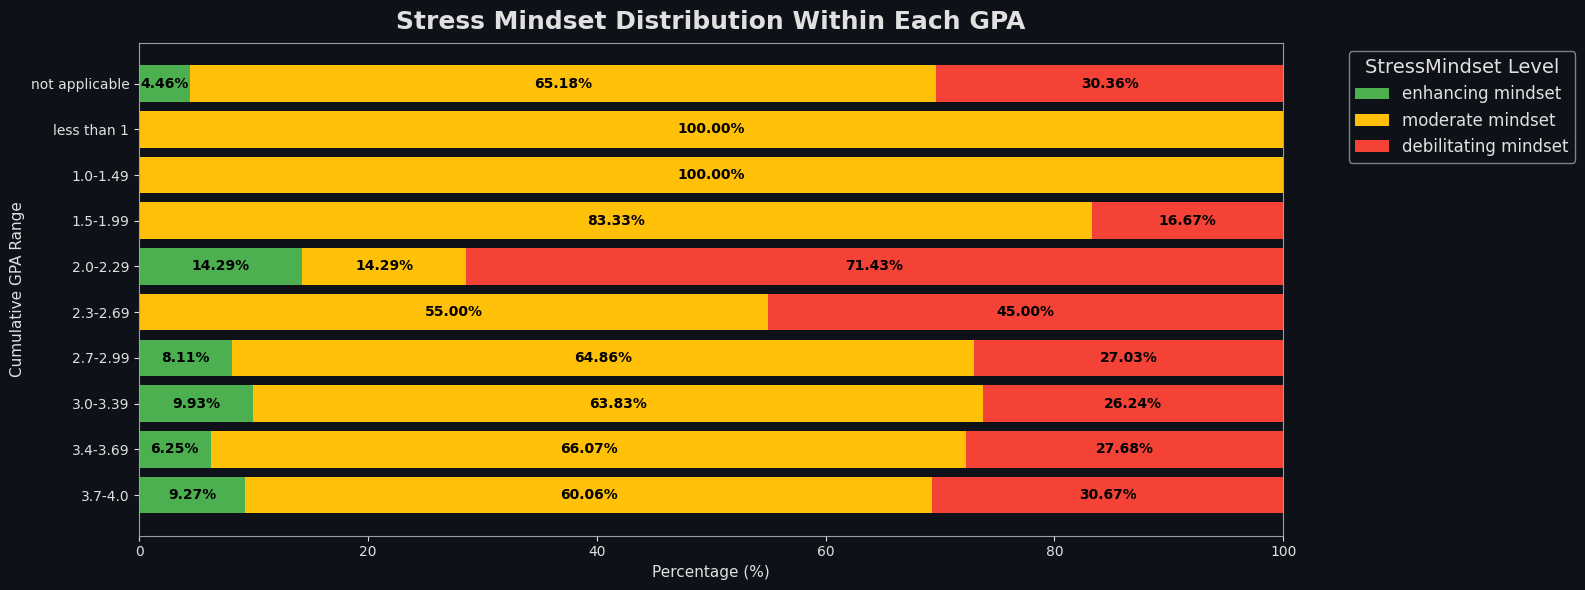

In [186]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    'figure.facecolor': '#0E1117',
    'axes.facecolor': '#0E1117',
    'axes.edgecolor': '#9E9E9E',
    'axes.labelcolor': '#E0E0E0',
    'xtick.color': '#E0E0E0',
    'ytick.color': '#E0E0E0',
    'text.color': '#E0E0E0'
})

gpa_order = [
    '3.7-4.0','3.4-3.69','3.0-3.39','2.7-2.99','2.3-2.69',
    '2.0-2.29','1.5-1.99','1.0-1.49','less than 1','not applicable'
]

stress_order = [
    'enhancing mindset',
    'moderate mindset',
    'debilitating mindset'
]

palette = {
    'enhancing mindset': '#4CAF50',
    'moderate mindset': '#FFC107',
    'debilitating mindset': '#F44336'
}

df_counts = research_df.groupby(['What is your cumulative GPA range?', 'StressMindset_Level']).size().unstack(fill_value=0)
df_counts = df_counts.reindex(gpa_order)
df_perc = df_counts.div(df_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16,6))

bottoms = pd.Series([0]*len(df_perc), index=df_perc.index)
for level in stress_order:
    ax.barh(
        df_perc.index,
        df_perc[level],
        left=bottoms,
        color=palette[level],
        label=level
    )
    bottoms += df_perc[level]

for i, gpa in enumerate(df_perc.index):
    left = 0
    for level in stress_order:
        perc = df_perc.loc[gpa, level]
        if perc > 0:
            ax.text(
                left + perc/2,
                i,
                f"{perc:.2f}%",
                ha='center',
                va='center',
                color='black',
                fontsize=10,
                fontweight='bold'
            )
        left += perc


ax.set_xlabel('Percentage (%)', fontsize=11)
ax.set_ylabel('Cumulative GPA Range', fontsize=11)
ax.set_title('Stress Mindset Distribution Within Each GPA', fontsize=18, fontweight='bold', pad=10)
ax.legend(title='StressMindset Level', title_fontsize=14, fontsize=12, frameon=True, facecolor='#0E1117', edgecolor='#9E9E9E', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlim(0,100)

plt.tight_layout()
plt.show()


In [187]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(research_df['FIES_level_enc'], research_df['income_enc'], nan_policy='omit')
print(f"Spearman r = {corr:.2f}, p-value = {p_value:.3e}")

if p_value < 0.05:
    print("يوجد ارتباط دال إحصائيًا بين FIES_level وIncome")
else:
    print("لا يوجد ارتباط دال إحصائيًا بين")


Spearman r = 0.39, p-value = 8.098e-33
يوجد ارتباط دال إحصائيًا بين FIES_level وIncome


/tmp/ipython-input-337615959.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balanced_df = research_df.groupby('What is the total income of your primary household?').sample(n=min_count, random_state=42)
/tmp/ipython-input-337615959.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_counts = balanced_df.groupby(['What is the total income of your primary household?', 'FIES_level']).size().unstack(fill_value=0)


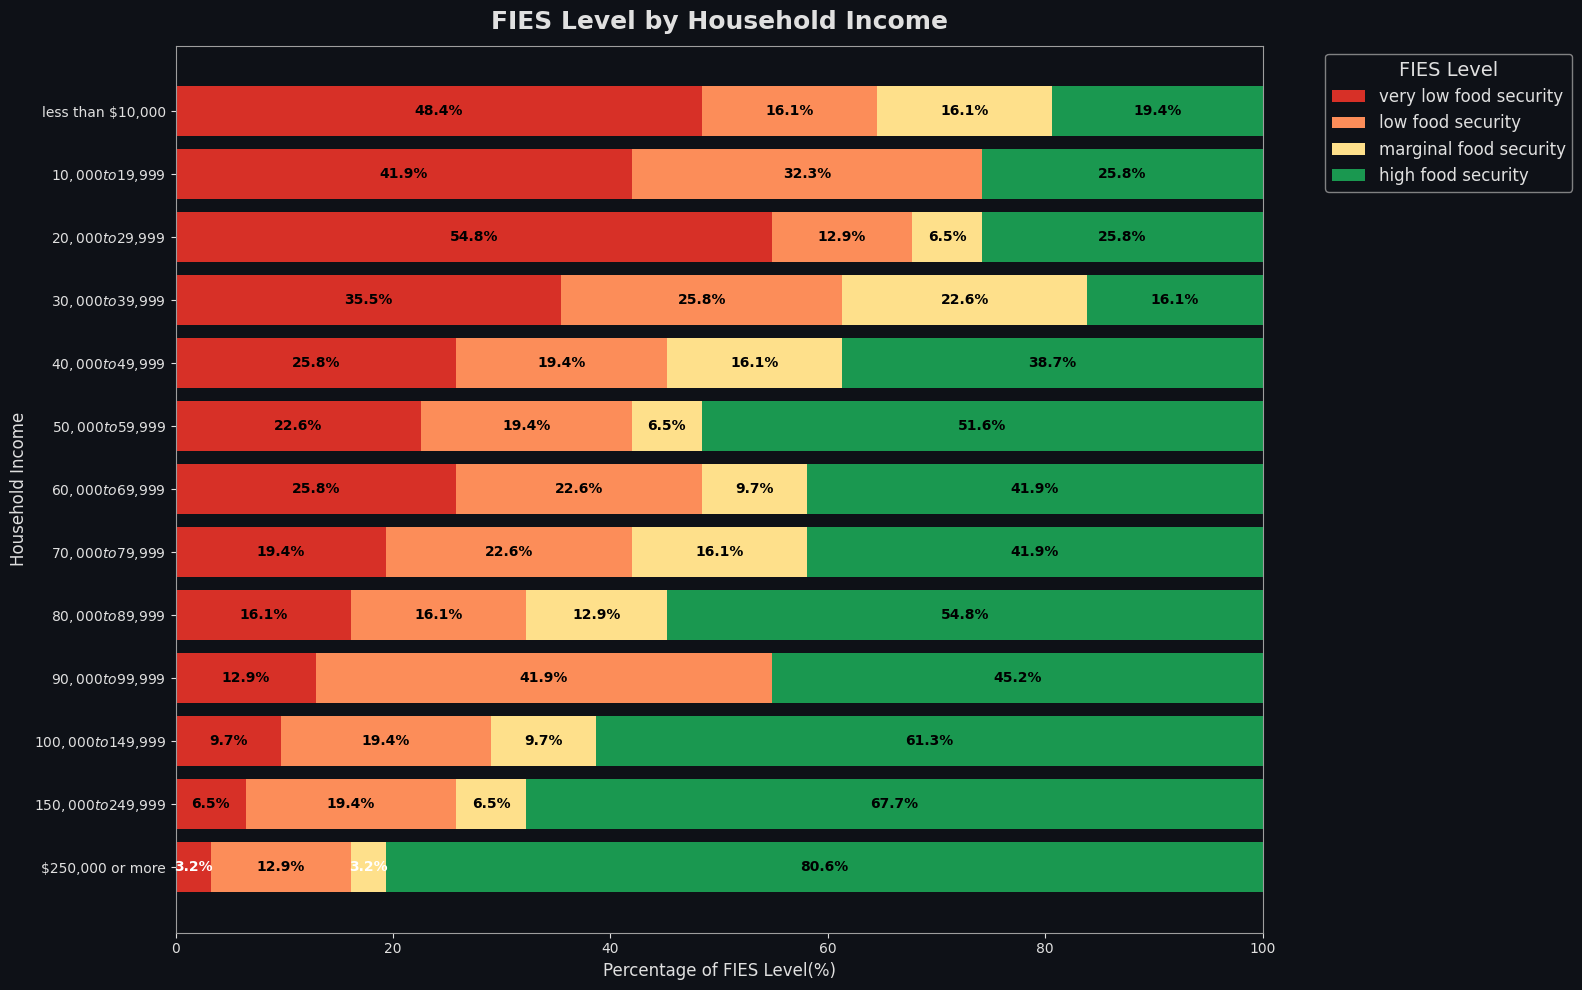

In [188]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    'figure.facecolor': '#0E1117',
    'axes.facecolor': '#0E1117',
    'axes.edgecolor': '#9E9E9E',
    'axes.labelcolor': '#E0E0E0',
    'xtick.color': '#E0E0E0',
    'ytick.color': '#E0E0E0',
    'text.color': '#E0E0E0'
})

income_order = [
    'less than $10,000',
    '$10,000 to $19,999',
    '$20,000 to $29,999',
    '$30,000 to $39,999',
    '$40,000 to $49,999',
    '$50,000 to $59,999',
    '$60,000 to $69,999',
    '$70,000 to $79,999',
    '$80,000 to $89,999',
    '$90,000 to $99,999',
    '$100,000 to $149,999',
    '$150,000 to $249,999',
    '$250,000 or more'
]

fies_order = ['very low food security', 'low food security', 'marginal food security', 'high food security']

fies_colors = {
    'very low food security': '#d73027',
    'low food security': '#fc8d59',
    'marginal food security': '#fee08b',
    'high food security': '#1a9850'
}

min_count = research_df['What is the total income of your primary household?'].value_counts().min()
balanced_df = research_df.groupby('What is the total income of your primary household?').sample(n=min_count, random_state=42)

df_counts = balanced_df.groupby(['What is the total income of your primary household?', 'FIES_level']).size().unstack(fill_value=0)
df_counts = df_counts.reindex(index=income_order, fill_value=0)
df_counts = df_counts[fies_order]
df_perc = df_counts.div(df_counts.sum(axis=1), axis=0) * 100
df_perc = df_perc.loc[df_perc.index[::-1]]

fig, ax = plt.subplots(figsize=(16,10))

bottoms = pd.Series([0]*len(df_perc), index=df_perc.index)
for level in fies_order:
    ax.barh(
        df_perc.index,
        df_perc[level],
        left=bottoms,
        color=fies_colors[level],
        label=level
    )
    bottoms += df_perc[level]

for i, income in enumerate(df_perc.index):
    left = 0
    for level in fies_order:
        perc = df_perc.loc[income, level]
        if perc > 0:
            ax.text(
                left + perc/2,
                i,
                f"{perc:.1f}%",
                ha='center',
                va='center',
                color='black' if perc > 5 else 'white',
                fontsize=10,
                fontweight='bold'
            )
        left += perc

ax.set_xlabel('Percentage of FIES Level(%)', fontsize=12)
ax.set_ylabel('Household Income', fontsize=12)
ax.set_title('FIES Level by Household Income', fontsize=18, fontweight='bold', pad=12)
ax.legend(title='FIES Level', title_fontsize=14, fontsize=12, frameon=True, facecolor='#0E1117', edgecolor='#9E9E9E', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlim(0,100)
plt.tight_layout()
ax.grid(False)
plt.show()


In [189]:
from scipy.stats import spearmanr

corr, p = spearmanr(
    research_df['gender_enc'],
    research_df['gpa_enc'],
    nan_policy='omit'
)

print(f"p-value = {p:.3e}")

if p < 0.05:
    print("يوجد ارتباط دال إحصائيًا بين الجنس وGPA")
else:
    print("لا يوجد ارتباط دال إحصائيًا بين الجنس وGPA")


p-value = 3.790e-01
لا يوجد ارتباط دال إحصائيًا بين الجنس وGPA


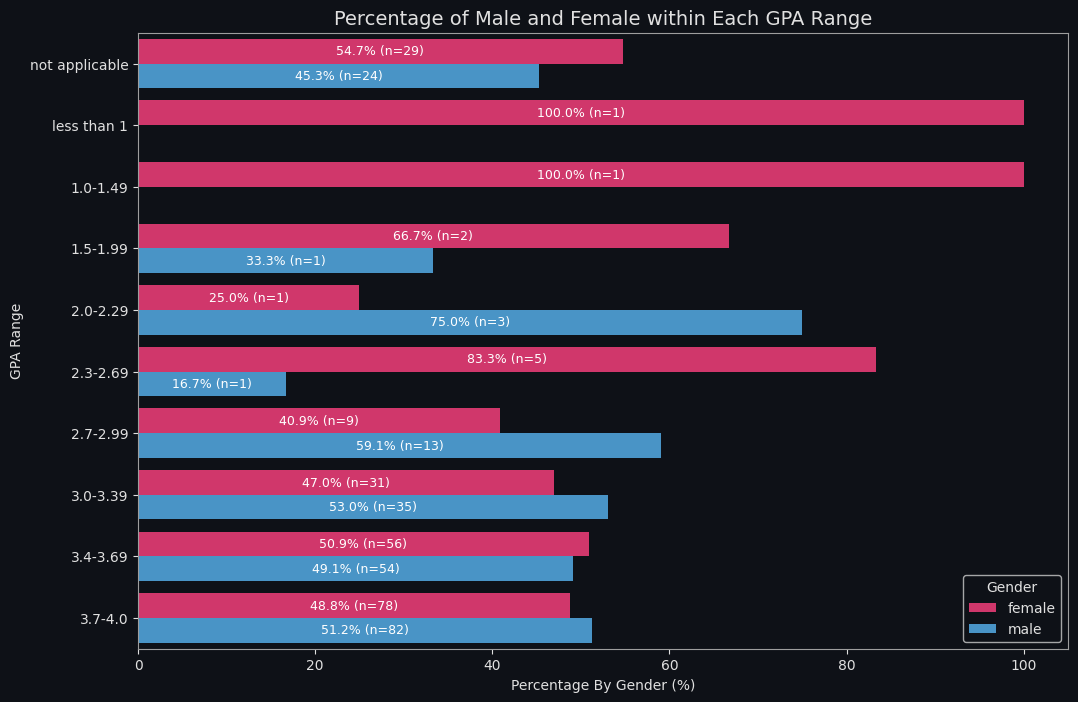

In [190]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

research_df.columns = research_df.columns.str.strip()

gpa_col = 'What is your cumulative GPA range?'
gender_col = 'What is your gender?'

gpa_order = [
    'not applicable', 'less than 1', '1.0-1.49', '1.5-1.99',
    '2.0-2.29', '2.3-2.69', '2.7-2.99', '3.0-3.39',
    '3.4-3.69', '3.7-4.0'
]

research_df[gpa_col] = pd.Categorical(
    research_df[gpa_col],
    categories=gpa_order,
    ordered=True
)

males = research_df[research_df[gender_col] == 'male']
females = research_df[research_df[gender_col] == 'female']
females_downsampled = females.sample(n=len(males), random_state=11)

balanced_df = pd.concat([males, females_downsampled])

counts = (
    balanced_df
    .groupby([gpa_col, gender_col], observed=True)
    .size()
    .reset_index(name='count')
)

counts['percentage'] = (
    counts.groupby(gpa_col, observed=True)['count']
    .transform(lambda x: x / x.sum() * 100)
)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=counts,
    y=gpa_col,
    x='percentage',
    hue=gender_col,
    palette={'male': '#3498db', 'female': '#e91e63'},
    order=gpa_order
)

for container, gender in zip(ax.containers, ax.legend_.texts):
    gender_name = gender.get_text()
    sub_df = counts[counts[gender_col] == gender_name]

    labels = [
        f"{p:.1f}% (n={c})"
        for p, c in zip(sub_df['percentage'], sub_df['count'])
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=9,
        color='white'
    )

plt.title('Percentage of Male and Female within Each GPA Range', fontsize=14)
plt.xlabel('Percentage By Gender (%)')
plt.ylabel('GPA Range')
plt.legend(title='Gender')

plt.show()


In [191]:
# Excel
research_df.to_excel("cleaned.xlsx", index=False)
files.download("cleaned.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [192]:
for col in research_df.columns:
    print(f"{col}: {research_df[col].unique()}")

What is your gender?: ['male' 'female']
What is your age?: ['18-22' '50 and older' '22-29' '40-49' '30-39' '23-29']
Are you currently enrolled in college?: ['yes' 'no']
What region do you live in ?: ['north america/central america' 'europe' 'asia' 'australia'
 'south america' 'middle east/north africa']
How many hours do you work in an average week during the school year?: ['not applicable' 'more than 40 hours' '11-20 hours' '21 to 30 hours'
 'less than 10 hours' 'i work seasonally' '31-40 hours']
Which of these describes your personal income last year?: [0 '$100,000 or greater' '$1 to $4,999' '30,000 to 49,999'
 'prefer not to answer' '$75,000 to 99,999' '4,999 to $9,999'
 '$50,000 to 74,999' '$10,000 to $19,999' '$20,000 to 29,999']
What is the total income of your primary household?: ['$90,000 to $99,999', '$100,000 to $149,999', '$250,000 or more', '$30,000 to $39,999', '$60,000 to $69,999', ..., '$20,000 to $29,999', '$10,000 to $19,999', '$80,000 to $89,999', '$70,000 to $79,999'